# 반도체 공정 스케줄링 시뮬레이션 결과

## 환경 설정

In [8]:
import os
import simpy
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = ['Noto Sans KR', 'Malgun Gothic', 'AppleGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# .env 파일의 환경 변수 로드
load_dotenv(override=True)

# .env 파일의 파라미터
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD = os.getenv('PM_HAZARD_THRESHOLD', '0.1')
PM_ACTIVE = os.getenv('PM_ACTIVE', 'True').lower() == 'true'
DOWN_ACTIVE = os.getenv('DOWN_ACTIVE', 'True').lower() == 'true'
MACHINE_RULE = os.getenv('MACHINE_RULE', 'SPTSSU')
JOB_RULE = os.getenv('JOB_RULE', 'random')
PM_RULE = os.getenv('PM_RULE', 'THRESHOLD')
DOWN_TIME_UNIT = os.getenv('DOWN_TIME_UNIT', 'M')
TIME_UNIT = os.getenv('TIME_UNIT', 'M')
print(f"BASE_DATA_PATH: {BASE_DATA_PATH}")
print(f"PM_HAZARD_THRESHOLD: {PM_HAZARD_THRESHOLD}")
print(f"PM_ACTIVE: {PM_ACTIVE}")
print(f"DOWN_ACTIVE: {DOWN_ACTIVE}")
print(f"MACHINE_RULE: {MACHINE_RULE}")
print(f"JOB_RULE: {JOB_RULE}")
print(f"PM_RULE: {PM_RULE}")
print(f"DOWN_TIME_UNIT: {DOWN_TIME_UNIT}")
print(f"TIME_UNIT: {TIME_UNIT}")

BASE_DATA_PATH: data
PM_HAZARD_THRESHOLD: 0.1
PM_ACTIVE: True
DOWN_ACTIVE: True
MACHINE_RULE: SPTSSU
JOB_RULE: SPT
PM_RULE: THRESHOLD
DOWN_TIME_UNIT: M
TIME_UNIT: H


## 모듈 import

In [9]:
from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Scheduler

## 데이터 로드

In [10]:
data_loader = DataLoader(BASE_DATA_PATH)

data = data_loader.load_all_data()

print("=" * 60)
print("데이터 개요")
print("=" * 60)
print(f"Jobs: {len(data['jobs'])} 개")
print(f"Operations: {len(data['operations'])} 개")
print(f"Machines: {len(data['machines'])} 개")
print(f"Machine Failures: {len(data['machine_failure'])} 개")
print(f"Setup Times: {len(data['setup_times'])} 개")
print(f"Operation-Machine Map: {len(data['operation_machine_map'])} 개")

데이터 개요
Jobs: 100 개
Operations: 1400 개
Machines: 60 개
Machine Failures: 60 개
Setup Times: 20 개
Operation-Machine Map: 27400 개


## 시뮬레이션 실행

In [11]:
# SimPy 환경 생성
env = simpy.Environment()

# 이벤트 로거 생성
event_logger = EventLogger(env)

# 스케줄러 생성
scheduler = Scheduler(env=env,
                      data=data,
                      event_logger=event_logger,
                      pm_hazard_threshold=float(PM_HAZARD_THRESHOLD))

In [12]:
env.run(until=scheduler.job_chk_process)
fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=event_logger.now,
    title=f"반도체 공정 간트 차트 (Simulation Time: {round(event_logger.now, 3)}{TIME_UNIT})")
fig.show()
fig.write_html("gantt_chart.html")

## 시뮬레이션 KPI 및 통계

### 작업별 통계

C:\Users\hun99\AppData\Local\Temp\ipykernel_8808\1591380400.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flowtime = job_info.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())


,flowtime,tardiness
id,,
J1,312.678,0
J10,253.148,0
J100,246.708,0
J11,311.658,0
J12,340.573,0
...,...,...
J95,180.090,0
J96,174.867,0
J97,144.686,0


C:\Users\hun99\AppData\Local\Temp\ipykernel_8808\1591380400.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  job_info['duration'] = round(job_info['finish'] - job_info['start'], 3)


waiting  setup  working  qtime_over job_type
id  op_id                                               
J1  J1_O1    89.461    0.0    7.353       0.000       P1
    J1_O10    0.000    0.0    8.074       0.000       P1
    J1_O11    0.000    0.0    2.942       0.000       P1
    J1_O12    0.000    0.0    8.466       0.000       P1
    J1_O13    0.000    0.0    3.118       0.000       P1
...             ...    ...      ...         ...      ...
J99 J99_O5    0.000    0.0    6.537       7.051       P2
    J99_O6    0.000    0.0    8.099       0.000       P2
    J99_O7    0.000    0.0    5.417       0.000       P2
    J99_O8    0.000    0.0    7.943       0.000       P2
    J99_O9    0.000    0.0    6.509       0.000       P2

[1400 rows x 5 columns]

Makespan: 365.813
Total Qtime Violation: 1304.29


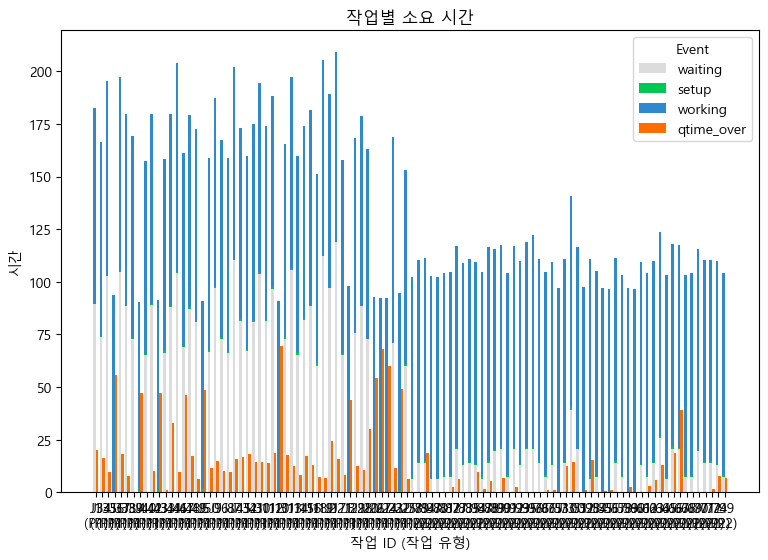

Job Type별 지표


,job_count,mean_flowtime,max_flowtime,mean_tardiness,max_tardiness,tardy_jobs,on_time_rate,mean_waiting,mean_setup,mean_working,mean_qtime_over
job_type,,,,,,,,,,,
P1,50,287.176,365.813,0.0,0,0,1.0,66.860,0.556,92.014,22.062
P2,50,165.771,246.708,0.0,0,0,1.0,12.024,0.503,96.678,4.024


Q-Time 위반 — Job Type × Transition


violation_count  total_violation  mean_violation
job_type transition                                                  
P1       G1-G3                    59          757.691          12.842
         G1-G4                    74          345.390           4.667
P2       G1-G3                    17           74.171           4.363
         G1-G4                    34          127.042           3.737

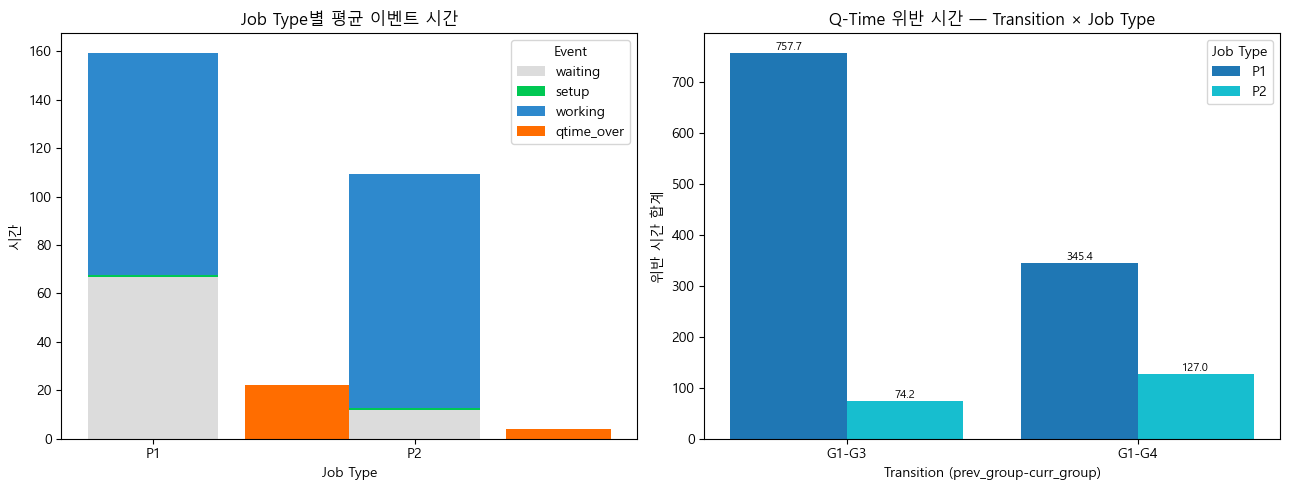

In [13]:
df_logs = pd.DataFrame(event_logger.logs)
job_info = df_logs[df_logs['resource'] == 'job']

flowtime = job_info.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
completed = job_info.groupby('id')['finish'].max()
job_duetime_map = data['jobs'].set_index('job_id')['due_date']
tardiness = completed.to_frame(name='completed').join(job_duetime_map, on='id')
tardiness = (tardiness['completed'] - tardiness['due_date']).apply(lambda x: max(x, 0)).to_frame(name='tardiness')
process_info = flowtime.to_frame(name='flowtime').join(tardiness, on='id')
display(round(process_info, 3))

job_info['duration'] = round(job_info['finish'] - job_info['start'], 3)
job_op_info = job_info.groupby(['id', 'op_id', 'event'], dropna=False)['duration'].sum().reset_index()
job_op_stacked = job_op_info.pivot(index=['id', 'op_id'], columns='event', values='duration').fillna(0)
job_op_stacked = job_op_stacked.reindex(columns=['waiting', 'setup', 'working', 'qtime_over'], fill_value=0)
job_type_map = data['jobs'].set_index('job_id')['job_type']
job_op_stacked = job_op_stacked.join(job_type_map, on='id')
display(job_op_stacked)
makespan = job_info['finish'].max()
print(f"Makespan: {round(makespan, 3)}")
print(f"Total Qtime Violation: {round(job_op_stacked['qtime_over'].sum(), 3)}")

job_info_sum = job_info.groupby(['id', 'event'])['duration'].sum().reset_index(['id', 'event'], drop=False)
job_stacked = job_info_sum.pivot(index='id', columns='event', values='duration').fillna(0)
job_stacked = job_stacked.reindex(columns=['waiting', 'setup', 'working', 'qtime_over'], fill_value=0)
job_stacked = job_stacked.join(job_type_map).sort_values('job_type')
job_stacked.index = [f"{i}\n({t})" for i, t in zip(job_stacked.index, job_stacked['job_type'])]
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(job_stacked))
width = 0.4

bottom = np.zeros(len(job_stacked))
for ev, color in zip(["waiting", "setup", "working"], ['#DCDCDC', '#00C853', '#2E89CD']):
    ax.bar(x - width/2, job_stacked[ev], width, label=ev, color=color, bottom=bottom)
    bottom += job_stacked[ev].values

ax.bar(x + width/2, job_stacked['qtime_over'], width, label='qtime_over', color='#FF6D00')

ax.set_xticks(x)
ax.set_xticklabels(job_stacked.index, rotation=0)
plt.title("작업별 소요 시간")
plt.xlabel("작업 ID (작업 유형)")
plt.ylabel("시간")
plt.legend(title="Event")
plt.show()

# ---------- Job Type별 지표 ----------
job_type_stats = process_info.join(job_type_map, on='id')
type_summary = job_type_stats.groupby('job_type').agg(
    job_count=('flowtime', 'size'),
    mean_flowtime=('flowtime', 'mean'),
    max_flowtime=('flowtime', 'max'),
    mean_tardiness=('tardiness', 'mean'),
    max_tardiness=('tardiness', 'max'),
    tardy_jobs=('tardiness', lambda x: (x > 0).sum()),
)
type_summary['on_time_rate'] = 1 - type_summary['tardy_jobs'] / type_summary['job_count']

# 이벤트별 시간 합계도 job_type별로 집계
job_stacked_with_type = job_info_sum.pivot(index='id', columns='event', values='duration').fillna(0)
job_stacked_with_type = job_stacked_with_type.reindex(columns=['waiting', 'setup', 'working', 'qtime_over'], fill_value=0)
job_stacked_with_type = job_stacked_with_type.join(job_type_map)
event_summary = job_stacked_with_type.groupby('job_type')[['waiting', 'setup', 'working', 'qtime_over']].mean()
event_summary.columns = [f"mean_{c}" for c in event_summary.columns]

type_summary = type_summary.join(event_summary)
print("Job Type별 지표")
display(round(type_summary, 3))

# ---------- Q-Time 위반 transition 분석 ----------
# 1) qtime_over 이벤트 추출
qtime_over_events = job_info[job_info['event'] == 'qtime_over'].copy()
qtime_over_events['violation'] = qtime_over_events['finish'] - qtime_over_events['start']

# 2) op_id로 (job_id, op_seq, op_group) 매핑 + 직전 op의 op_group 결합
op_meta = data['operations'][['job_id', 'op_id', 'op_seq', 'op_group']].copy()
prev_op_meta = op_meta.copy()
prev_op_meta['op_seq'] = prev_op_meta['op_seq'] + 1
prev_op_meta = prev_op_meta.rename(columns={'op_group': 'prev_op_group'})[['job_id', 'op_seq', 'prev_op_group']]
op_with_prev = op_meta.merge(prev_op_meta, on=['job_id', 'op_seq'], how='left')
op_with_prev['transition'] = op_with_prev['prev_op_group'] + '-' + op_with_prev['op_group']

# 3) qtime_over 이벤트와 매핑 + job_type 결합
qtime_over_events = qtime_over_events.merge(
    op_with_prev[['op_id', 'transition']], on='op_id', how='left'
)
qtime_over_events = qtime_over_events.rename(columns={'id': 'job_id'}).join(job_type_map, on='job_id')

# 4) (job_type, transition)별 집계
transition_summary = qtime_over_events.groupby(['job_type', 'transition']).agg(
    violation_count=('violation', 'size'),
    total_violation=('violation', 'sum'),
    mean_violation=('violation', 'mean'),
).round(3)
print("Q-Time 위반 — Job Type × Transition")
display(transition_summary)

# 시각화: 좌) job_type별 평균 이벤트 시간 / 우) transition별 위반 시간 합계
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(event_summary))
bottom = np.zeros(len(event_summary))
for ev, color in zip(["mean_waiting", "mean_setup", "mean_working"], ['#DCDCDC', '#00C853', '#2E89CD']):
    axes[0].bar(x, event_summary[ev], 0.5, label=ev.replace('mean_', ''), color=color, bottom=bottom)
    bottom += event_summary[ev].values
axes[0].bar(x + 0.55, event_summary['mean_qtime_over'], 0.4, label='qtime_over', color='#FF6D00')
axes[0].set_xticks(x)
axes[0].set_xticklabels(event_summary.index, rotation=0)
axes[0].set_title("Job Type별 평균 이벤트 시간")
axes[0].set_xlabel("Job Type")
axes[0].set_ylabel("시간")
axes[0].legend(title="Event")

# transition × job_type 그룹 막대 차트
total_violation_pivot = transition_summary['total_violation'].unstack('job_type').fillna(0)
transitions = total_violation_pivot.index.tolist()
job_types_list = total_violation_pivot.columns.tolist()
n_types = len(job_types_list)
bar_width = 0.8 / max(n_types, 1)
x = np.arange(len(transitions))
colors = plt.cm.tab10(np.linspace(0, 1, max(n_types, 1)))
for i, jt in enumerate(job_types_list):
    offset = (i - (n_types - 1) / 2) * bar_width
    bars = axes[1].bar(x + offset, total_violation_pivot[jt], bar_width, label=jt, color=colors[i])
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            axes[1].text(bar.get_x() + bar.get_width() / 2, h, f'{h:.1f}',
                         ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(transitions, rotation=0)
axes[1].set_title("Q-Time 위반 시간 — Transition × Job Type")
axes[1].set_xlabel("Transition (prev_group-curr_group)")
axes[1].set_ylabel("위반 시간 합계")
axes[1].legend(title="Job Type")

plt.tight_layout()
plt.show()

### 공정별 설비 활용률

C:\Users\hun99\AppData\Local\Temp\ipykernel_8808\2410717873.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  machine_info['utilization'] = machine_info['finish'] - machine_info['start']


,utilization,group
id,,
M1,0.860211,G1
M10,0.564424,G1
M11,0.556790,G1
M12,0.438931,G1
M13,0.437446,G1
M14,0.441885,G1
M15,0.431327,G1
M16,0.426321,G1
M17,0.409592,G1


C:\Users\hun99\AppData\Local\Temp\ipykernel_8808\2410717873.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=machine_utilization, x='group', y='utilization',


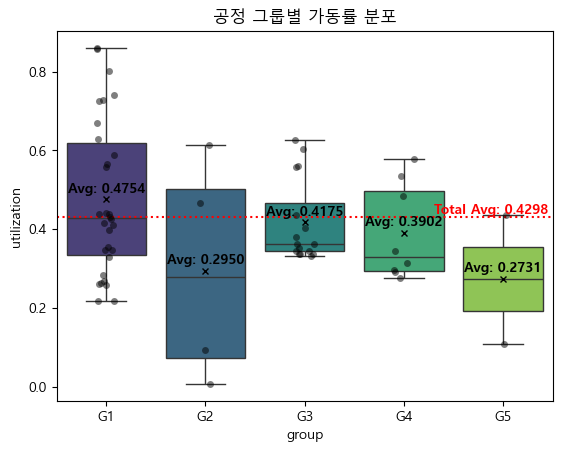

: 

In [ ]:
df_logs = pd.DataFrame(event_logger.logs)
machine_info = df_logs[df_logs['resource'] == 'machine']
machine_info['utilization'] = machine_info['finish'] - machine_info['start']
machine_utilization = pd.DataFrame(machine_info[machine_info['event'].str.startswith('working')].groupby('id')['utilization'].sum() / makespan)
machine_utilization['group'] = data['machines'].set_index('machine_id').loc[machine_utilization.index]['machine_group']
display(machine_utilization)
group_means = machine_utilization.groupby('group')['utilization'].mean()
total_mean = machine_utilization['utilization'].mean()
sns.boxplot(data=machine_utilization, x='group', y='utilization', 
            palette='viridis', showmeans=True,
            meanprops={"marker":"x", "markeredgecolor":"black", "markersize":"5"})
sns.stripplot(data=machine_utilization, x='group', y='utilization', 
              color='black', alpha=0.5, jitter=True)
for i, group in enumerate(group_means.index):
    mean_val = group_means[group]
    plt.text(i, mean_val + 0.01, f'Avg: {mean_val:.4f}', 
             ha='center', va='bottom', color='black', fontweight='bold')
plt.text(len(group_means)-0.55, total_mean + 0.01, f'Total Avg: {total_mean:.4f}', color='red', fontweight='bold', ha='right')
plt.axhline(total_mean, color='red', linestyle=':')
plt.title("공정 그룹별 가동률 분포")
plt.show()